# **ANALISIS KLASIFIKASI TINGKAT OBESITAS BERDASARKAN POLA HIDUP DAN AKTIVITAS FISIK DENGAN PENDEKATAN ALGORITMA MACHINE LEARNING**

**1. IMPORT LIBRARY**


In [2]:
import pandas as pd

**2. LOAD DATASET**

In [3]:
df = pd.read_excel('dataset machine learning.xlsx')
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,Nobeyesdad
0,21,Female,1.62,64.0,no,no,2,3,no,no,2,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21,Female,1.52,56.0,Sometimes,no,3,3,yes,yes,3,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23,Male,1.80,77.0,Frequently,no,2,3,no,no,2,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27,Male,1.80,87.0,Frequently,no,3,3,no,no,2,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22,Male,1.78,89.8,Sometimes,no,2,1,no,no,2,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


**3. FITUR/VARIABEL**


In [4]:
# Menampilkan nama kolom
print(df.columns)

# Info dataset
df.info()

Index(['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP',
       'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE',
       'CAEC', 'MTRANS', 'Nobeyesdad'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2157 entries, 0 to 2156
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2157 non-null   int64  
 1   Gender                          2157 non-null   object 
 2   Height                          2157 non-null   float64
 3   Weight                          2157 non-null   float64
 4   CALC                            2157 non-null   object 
 5   FAVC                            2157 non-null   object 
 6   FCVC                            2157 non-null   int64  
 7   NCP                             2157 non-null   int64  
 8   SCC                             2157 non-null   object 
 9   S

**4. STATISTIK DESKRIPTIF**


In [5]:
# Statistik deskriptif untuk data numerik
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2.157000e+03,2.157000e+03,2.157000e+03,2.157000e+03,2.157000e+03,2.157000e+03,2.157000e+03,2.157000e+03
mean,1.458019e+07,1.101929e+06,5.726101e+07,7.956093e+05,6.668842e+05,1.133746e+06,4.190552e+05,1.780532e+05
std,1.311363e+07,8.094192e+05,4.995305e+07,1.130888e+06,1.174115e+06,1.097236e+06,7.575843e+05,4.847934e+05
min,1.400000e+01,1.450000e+00,3.800000e+01,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.300000e+01,1.800000e+00,8.000000e+01,2.000000e+00,3.000000e+00,2.000000e+00,1.304170e-01,0.000000e+00
50%,1.902757e+07,1.627396e+06,6.640141e+07,3.000000e+00,3.000000e+00,1.170515e+06,1.000000e+00,6.485220e-01
75%,2.407997e+07,1.745602e+06,1.047550e+08,2.047069e+06,1.116401e+06,2.151496e+06,2.160790e+05,1.000000e+00
max,5.513788e+07,1.975663e+06,1.650573e+08,2.998441e+06,3.999591e+06,2.999495e+06,2.999918e+06,1.990617e+06


In [6]:
df.describe(include='all')

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,Nobeyesdad
count,2.157000e+03,2157,2.157000e+03,2.157000e+03,2157,2157,2.157000e+03,2.157000e+03,2157,2157,2.157000e+03,2157,2.157000e+03,2.157000e+03,2157,2157,2157
unique,NaN,2,NaN,NaN,4,2,NaN,NaN,2,2,NaN,2,NaN,NaN,4,5,7
top,NaN,Male,NaN,NaN,Sometimes,yes,NaN,NaN,no,no,NaN,yes,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,NaN,1090,NaN,NaN,1401,1898,NaN,NaN,2057,2111,NaN,1733,NaN,NaN,1801,1581,352
mean,1.458019e+07,NaN,1.101929e+06,5.726101e+07,NaN,NaN,7.956093e+05,6.668842e+05,NaN,NaN,1.133746e+06,NaN,4.190552e+05,1.780532e+05,NaN,NaN,NaN
std,1.311363e+07,NaN,8.094192e+05,4.995305e+07,NaN,NaN,1.130888e+06,1.174115e+06,NaN,NaN,1.097236e+06,NaN,7.575843e+05,4.847934e+05,NaN,NaN,NaN
min,1.400000e+01,NaN,1.450000e+00,3.800000e+01,NaN,NaN,1.000000e+00,1.000000e+00,NaN,NaN,1.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN
25%,2.300000e+01,NaN,1.800000e+00,8.000000e+01,NaN,NaN,2.000000e+00,3.000000e+00,NaN,NaN,2.000000e+00,NaN,1.304170e-01,0.000000e+00,NaN,NaN,NaN
50%,1.902757e+07,NaN,1.627396e+06,6.640141e+07,NaN,NaN,3.000000e+00,3.000000e+00,NaN,NaN,1.170515e+06,NaN,1.000000e+00,6.485220e-01,NaN,NaN,NaN
75%,2.407997e+07,NaN,1.745602e+06,1.047550e+08,NaN,NaN,2.047069e+06,1.116401e+06,NaN,NaN,2.151496e+06,NaN,2.160790e+05,1.000000e+00,NaN,NaN,NaN


# **DATA PREPROSESING**

**1. CEK DATA KOSONG**


In [7]:
df.isnull().sum()

,0
Age,0
Gender,0
Height,0
Weight,0
CALC,0
FAVC,0
FCVC,0
NCP,0
SCC,0
SMOKE,0


**2. CEK DUPLIKASI**

In [8]:
df.duplicated().sum()

np.int64(24)

In [9]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 2157
Jumlah kolom: 17


**3. PISAHKAN FITUR DAN TARGET**

In [10]:
X = df.drop('Nobeyesdad', axis=1)
y = df['Nobeyesdad']

**4. HANDLING MISSING VALUES**

In [11]:
# numerik → mean
for col in X.select_dtypes(include=['int64', 'float64']).columns:
    X[col].fillna(X[col].mean(), inplace=True)

# kategori → modus
for col in X.select_dtypes(include=['object']).columns:
    X[col].fillna(X[col].mode()[0], inplace=True)

/tmp/ipykernel_1532/3153252041.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mean(), inplace=True)
/tmp/ipykernel_1532/3153252041.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

**5. ENCODING DATA KATEGORI**





In [12]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include=['object']).columns:
    temp_le = LabelEncoder()
    X[col] = temp_le.fit_transform(X[col])

le = LabelEncoder()
y = le.fit_transform(y)

feature_names = df.drop('Nobeyesdad', axis=1).columns.tolist()

encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le_temp = LabelEncoder()
    df[col] = le_temp.fit_transform(df[col])
    encoders[col] = le_temp


**6. MENANGANI OUTLIER**

In [13]:
import numpy as np

for col in X.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X[col] = np.where(X[col] < lower, lower, X[col])
    X[col] = np.where(X[col] > upper, upper, X[col])

**7. SCALLING**

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

**8. SPLIT DATA TRAINING DAN TESTING**

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**9. HANDLE IMBALANCE**

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# **EKSPLORASI DATA**

**1. IMPORT LIBRARY VISUALISASI**

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

**2. DISTRIBUSI FITUR NUMERIK**

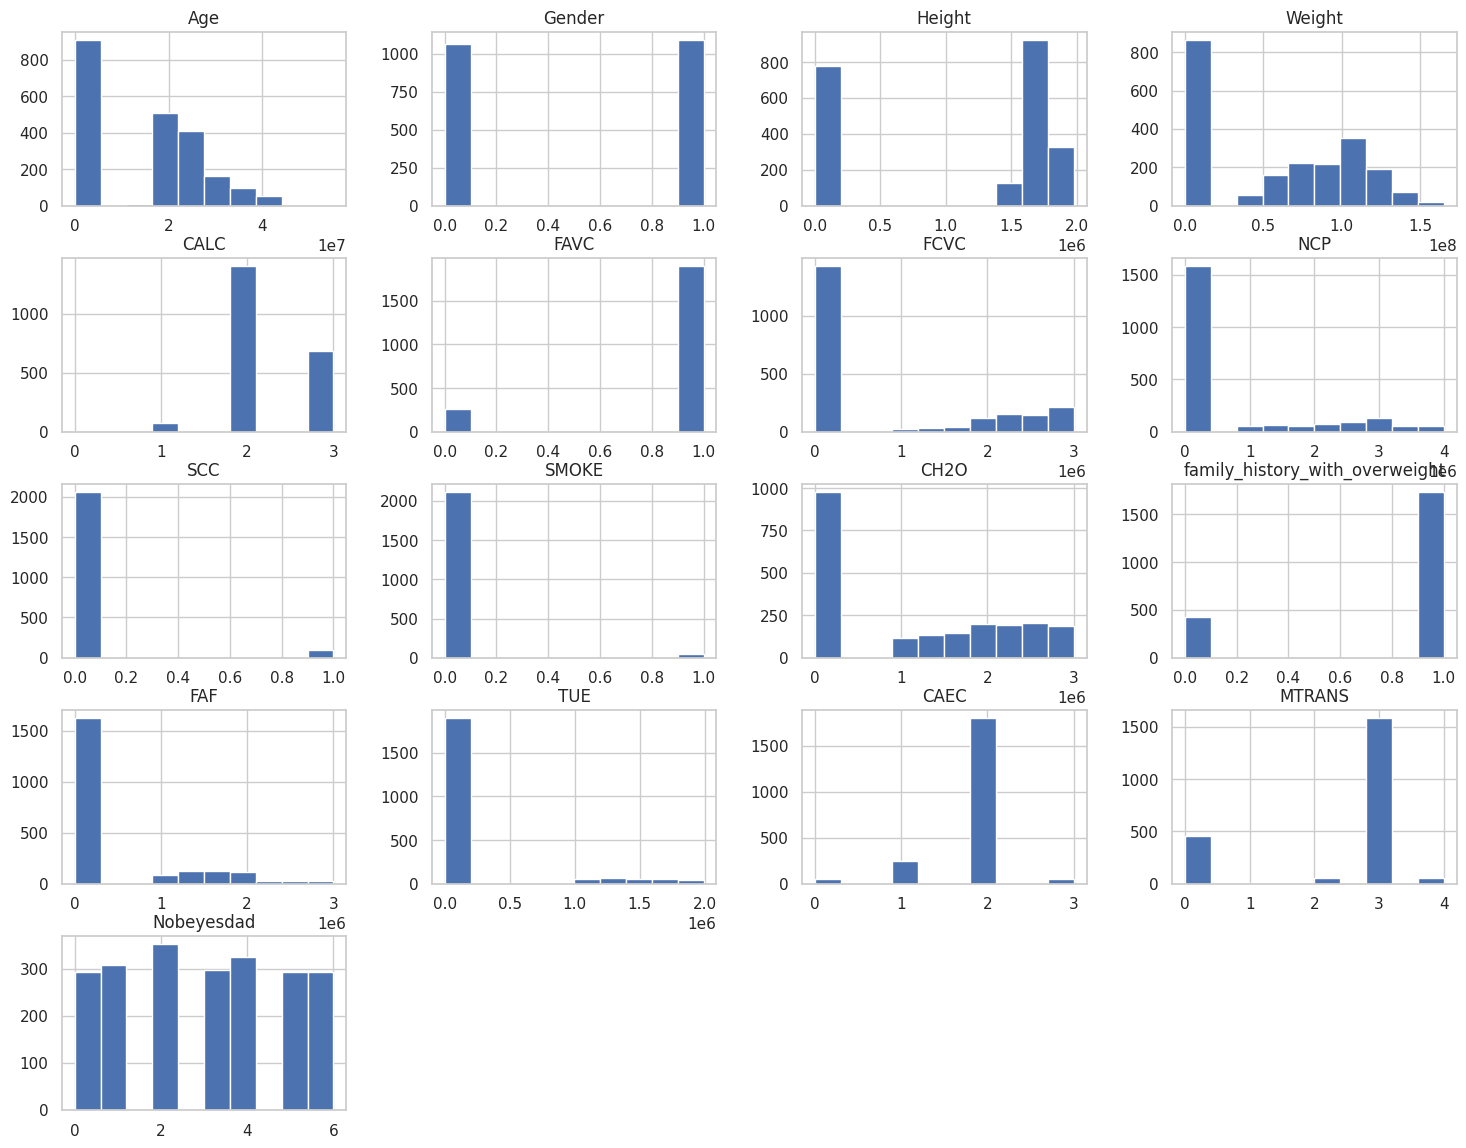

In [92]:
df.hist(figsize=(18,14))
plt.show()

**3. DISTRIBUSI TARGET**

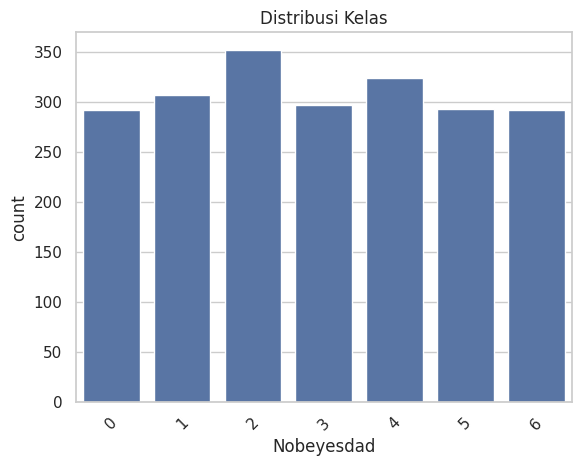

In [19]:
sns.countplot(x='Nobeyesdad', data=df)
plt.title('Distribusi Kelas')
plt.xticks(rotation=45)
plt.show()

**4. BOXPLOT**

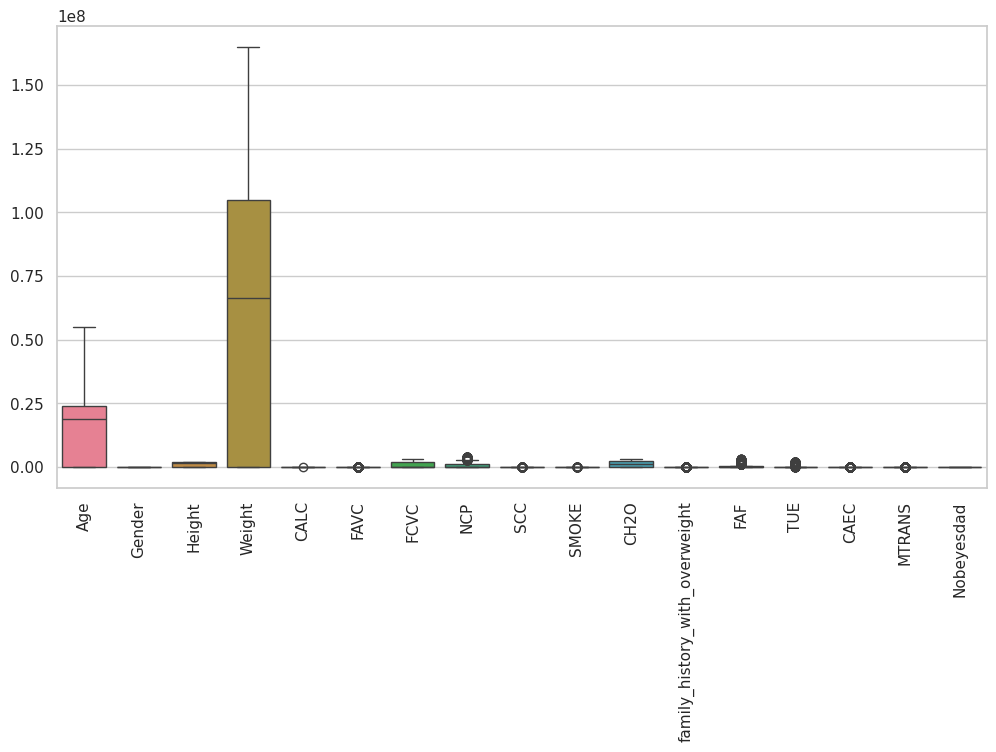

In [20]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

**5. HEATMAP KORELASI**

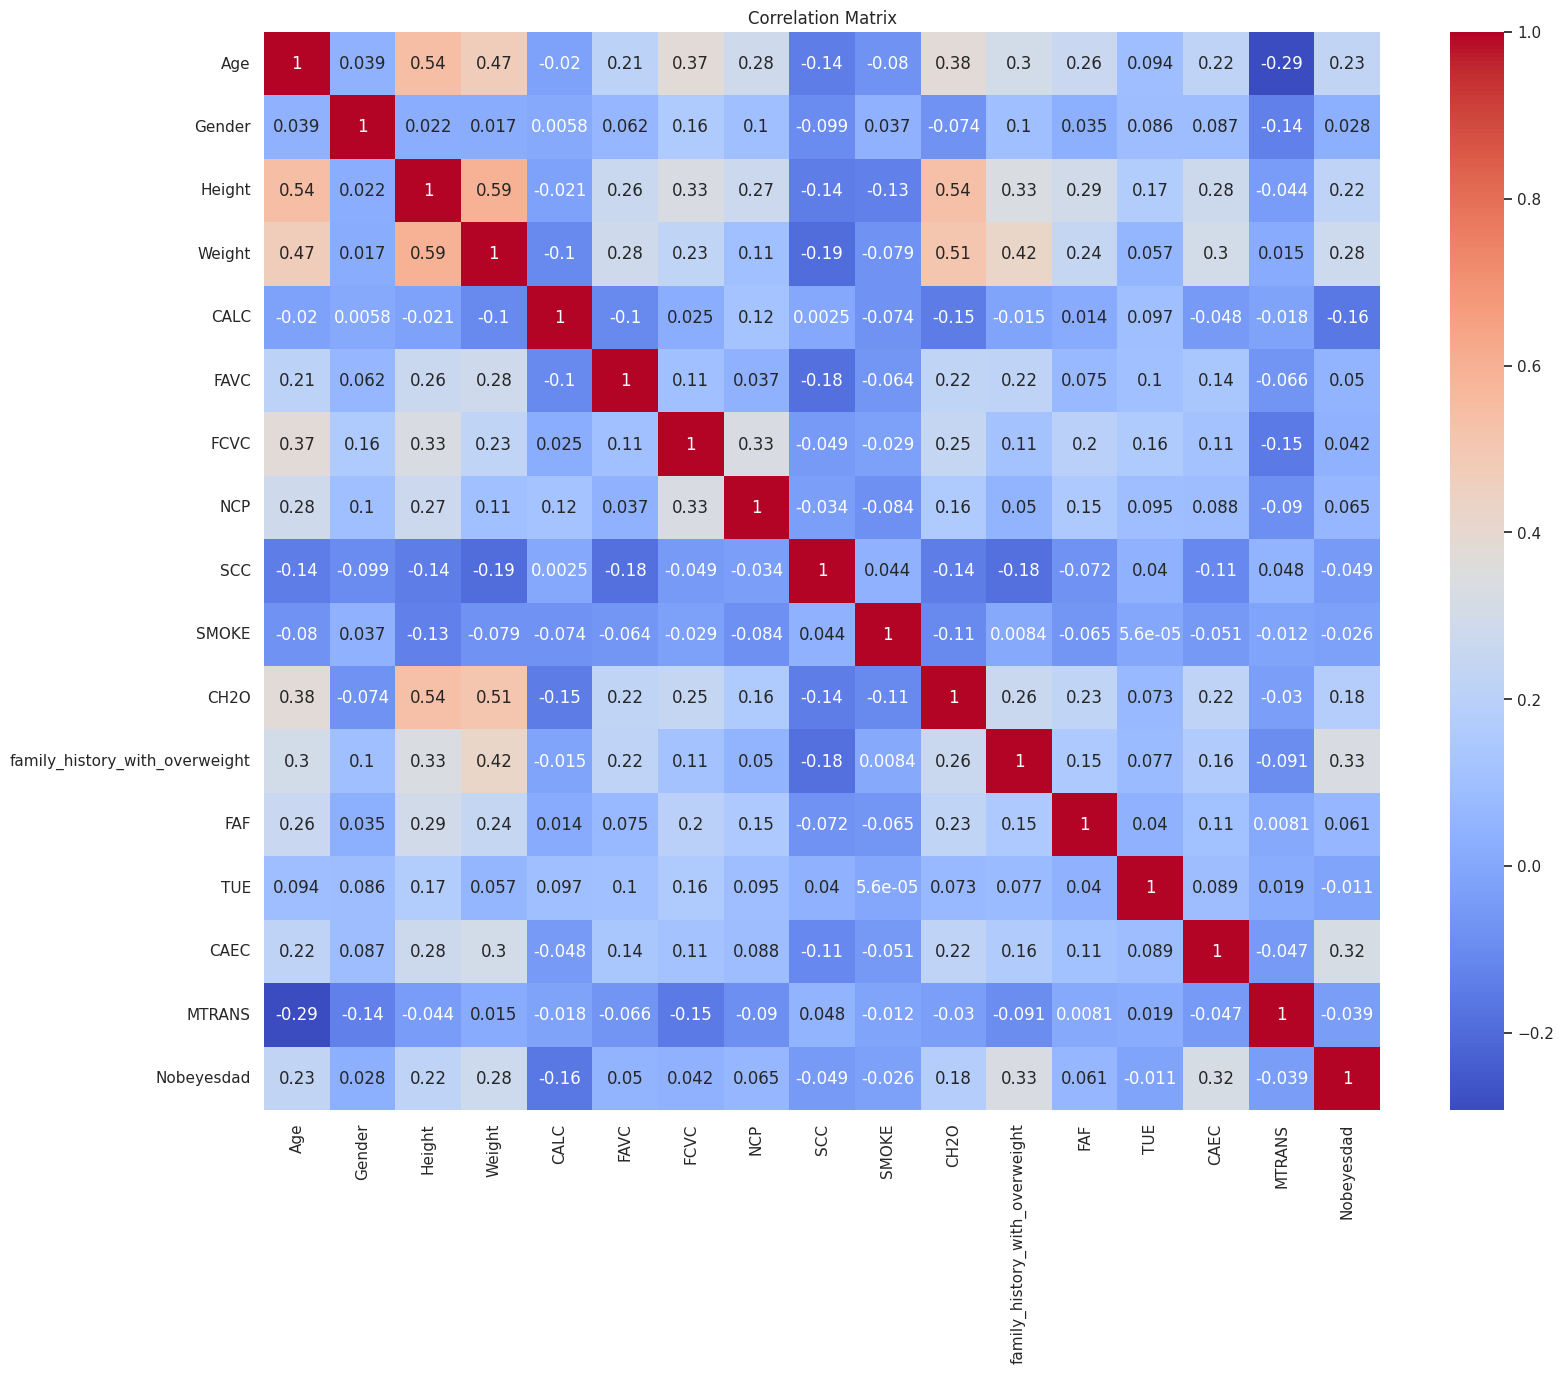

In [93]:
plt.figure(figsize=(18,14))

# hanya numerik
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**6. HUBUNGAN FITUR DENGAN TARGET**

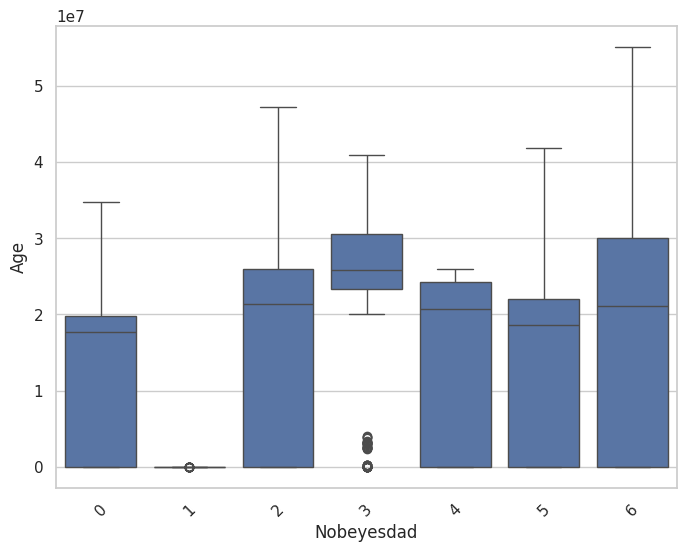

In [22]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Nobeyesdad', y='Age', data=df)
plt.xticks(rotation=45)
plt.show()

# **DATA SPLITTING**

**1. VARIASI 1 → 80% : 20%**

In [23]:
from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**2. VARIASI 2 → 70% : 30%**

In [24]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

**3. VARIASI 3 → 90% : 10%**

In [25]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

**4. CEK JUMLAH DATA**

In [26]:
print("80:20 ->", X_train1.shape, X_test1.shape)
print("70:30 ->", X_train2.shape, X_test2.shape)
print("90:10 ->", X_train3.shape, X_test3.shape)

80:20 -> (1725, 16) (432, 16)
70:30 -> (1509, 16) (648, 16)
90:10 -> (1941, 16) (216, 16)


# **MODEL BUILDING**

**SMOTE**

In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train1, y_train1 = smote.fit_resample(X_train1, y_train1)

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**1. RANDOM FOREST**

In [29]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

model_rf.fit(X_train1, y_train1)
y_pred_rf = model_rf.predict(X_test1)

print("Random Forest:", accuracy_score(y_test1, y_pred_rf))
print(classification_report(y_test1, y_pred_rf))

Random Forest: 0.8773148148148148
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        58
           1       0.75      0.94      0.83        62
           2       0.89      0.92      0.90        71
           3       1.00      0.93      0.96        59
           4       1.00      0.98      0.99        65
           5       0.75      0.73      0.74        59
           6       0.88      0.72      0.79        58

    accuracy                           0.88       432
   macro avg       0.88      0.87      0.87       432
weighted avg       0.88      0.88      0.88       432



**2. XGBOOST**

In [30]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model_xgb.fit(X_train1, y_train1)
y_pred_xgb = model_xgb.predict(X_test1)

print("XGBoost:", accuracy_score(y_test1, y_pred_xgb))
print(classification_report(y_test1, y_pred_xgb))

XGBoost: 0.8935185185185185
              precision    recall  f1-score   support

           0       0.92      0.93      0.92        58
           1       0.81      0.92      0.86        62
           2       0.86      0.93      0.89        71
           3       1.00      0.93      0.96        59
           4       1.00      0.98      0.99        65
           5       0.84      0.73      0.78        59
           6       0.84      0.81      0.82        58

    accuracy                           0.89       432
   macro avg       0.90      0.89      0.89       432
weighted avg       0.90      0.89      0.89       432



**3. HIST GRADIENT BOOSTING**

In [31]:
from sklearn.ensemble import HistGradientBoostingClassifier

model_hgb = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)

model_hgb.fit(X_train1, y_train1)
y_pred_hgb = model_hgb.predict(X_test1)

print("Hist Gradient Boosting:", accuracy_score(y_test1, y_pred_hgb))
print(classification_report(y_test1, y_pred_hgb))

Hist Gradient Boosting: 0.9212962962962963
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        58
           1       0.91      0.95      0.93        62
           2       0.86      0.94      0.90        71
           3       1.00      0.92      0.96        59
           4       1.00      0.98      0.99        65
           5       0.85      0.85      0.85        59
           6       0.91      0.84      0.88        58

    accuracy                           0.92       432
   macro avg       0.92      0.92      0.92       432
weighted avg       0.92      0.92      0.92       432



**4. PERBANDINGAN AKURASI FINAL**

In [32]:
results = {
    "Random Forest": accuracy_score(y_test1, y_pred_rf),
    "XGBoost": accuracy_score(y_test1, y_pred_xgb),
    "Hist Gradient Boosting": accuracy_score(y_test1, y_pred_hgb)
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Random Forest: 0.8773
XGBoost: 0.8935
Hist Gradient Boosting: 0.9213


# **HYPERPARAMETER TUNING**

**1. TUNING RANDOM FOREST**

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

param_rf = {
    'n_estimators': [300, 500],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 5],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=3,
    n_jobs=-1
)

grid_rf.fit(X_train1, y_train1)

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test1)

print("Best Random Forest:", accuracy_score(y_test1, y_pred_rf))
print("Best Params RF:", grid_rf.best_params_)

Best Random Forest: 0.8726851851851852
Best Params RF: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 500}


**2. TUNING XGBOOST**

In [34]:
from xgboost import XGBClassifier

param_xgb = {
    'n_estimators': [400, 600],
    'learning_rate': [0.03, 0.05],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=42),
    param_xgb,
    cv=3,
    n_jobs=-1
)

grid_xgb.fit(X_train1, y_train1)

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test1)

print("Best XGBoost:", accuracy_score(y_test1, y_pred_xgb))
print("Best Params XGB:", grid_xgb.best_params_)

Best XGBoost: 0.8819444444444444
Best Params XGB: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400, 'subsample': 1.0}


**3. TUNING HIST GRADIENT BOOSTING**

In [35]:
from sklearn.ensemble import HistGradientBoostingClassifier

param_hgb = {
    'max_iter': [300, 500],
    'learning_rate': [0.03, 0.05],
    'max_depth': [8, 10]
}

grid_hgb = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_hgb,
    cv=3,
    n_jobs=-1
)

grid_hgb.fit(X_train1, y_train1)

best_hgb = grid_hgb.best_estimator_

y_pred_hgb = best_hgb.predict(X_test1)

print("Best Hist GB:", accuracy_score(y_test1, y_pred_hgb))
print("Best Params HGB:", grid_hgb.best_params_)

Best Hist GB: 0.9212962962962963
Best Params HGB: {'learning_rate': 0.03, 'max_depth': 10, 'max_iter': 500}


**4. PERBANDINGAN SETELAH TUNING**

In [36]:
results = {
    "Random Forest": accuracy_score(y_test1, y_pred_rf),
    "XGBoost": accuracy_score(y_test1, y_pred_xgb),
    "Hist Gradient Boosting": accuracy_score(y_test1, y_pred_hgb)
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Random Forest: 0.8727
XGBoost: 0.8819
Hist Gradient Boosting: 0.9213


# **MODEL EVALUATION**

**1. METRIK EVALUASI**

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

print("=== Random Forest ===")
print(classification_report(y_test1, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        58
           1       0.75      0.94      0.83        62
           2       0.88      0.92      0.90        71
           3       1.00      0.93      0.96        59
           4       1.00      0.98      0.99        65
           5       0.75      0.69      0.72        59
           6       0.86      0.72      0.79        58

    accuracy                           0.87       432
   macro avg       0.88      0.87      0.87       432
weighted avg       0.88      0.87      0.87       432



In [38]:
print("=== XGBoost ===")
print(classification_report(y_test1, y_pred_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        58
           1       0.84      0.92      0.88        62
           2       0.86      0.89      0.88        71
           3       0.97      0.97      0.97        59
           4       1.00      0.98      0.99        65
           5       0.79      0.75      0.77        59
           6       0.78      0.74      0.76        58

    accuracy                           0.88       432
   macro avg       0.88      0.88      0.88       432
weighted avg       0.88      0.88      0.88       432



In [39]:
print("=== Hist Gradient Boosting ===")
print(classification_report(y_test1, y_pred_hgb))

=== Hist Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.96      0.93      0.95        58
           1       0.88      0.95      0.91        62
           2       0.87      0.94      0.91        71
           3       1.00      0.92      0.96        59
           4       1.00      0.98      0.99        65
           5       0.85      0.85      0.85        59
           6       0.91      0.86      0.88        58

    accuracy                           0.92       432
   macro avg       0.92      0.92      0.92       432
weighted avg       0.92      0.92      0.92       432



**2. CONFUSION MATRIX (MODEL TERBAIK)**

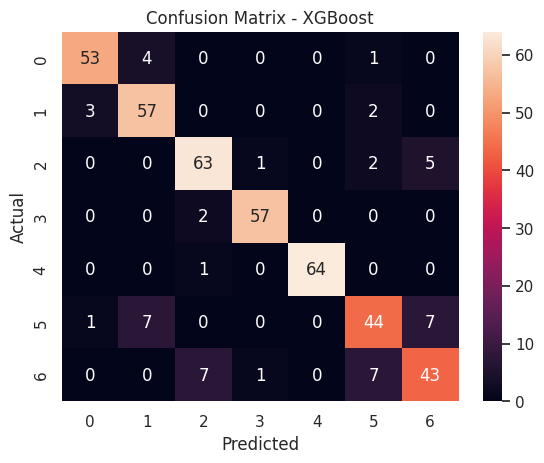

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test1, y_pred_xgb)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**3. PERBANDINGAN SEMUA MODEL**

In [41]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

evaluation = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Hist Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test1, y_pred_rf),
        accuracy_score(y_test1, y_pred_xgb),
        accuracy_score(y_test1, y_pred_hgb)
    ],
    'Precision': [
        precision_score(y_test1, y_pred_rf, average='weighted'),
        precision_score(y_test1, y_pred_xgb, average='weighted'),
        precision_score(y_test1, y_pred_hgb, average='weighted')
    ],
    'Recall': [
        recall_score(y_test1, y_pred_rf, average='weighted'),
        recall_score(y_test1, y_pred_xgb, average='weighted'),
        recall_score(y_test1, y_pred_hgb, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test1, y_pred_rf, average='weighted'),
        f1_score(y_test1, y_pred_xgb, average='weighted'),
        f1_score(y_test1, y_pred_hgb, average='weighted')
    ]
})

print(evaluation)

                    Model  Accuracy  Precision    Recall  F1-Score
0           Random Forest  0.872685   0.876765  0.872685  0.872207
1                 XGBoost  0.881944   0.881660  0.881944  0.881344
2  Hist Gradient Boosting  0.921296   0.923685  0.921296  0.921660


**4. VISUALISASI PERBANDINGAN**

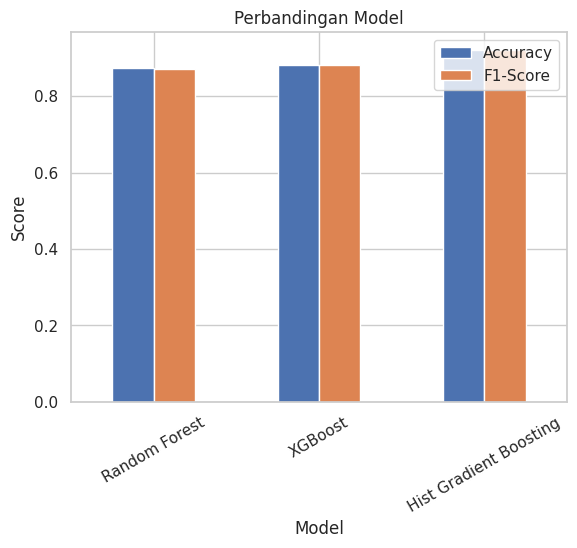

In [42]:
import matplotlib.pyplot as plt

evaluation.set_index('Model')[['Accuracy', 'F1-Score']].plot(kind='bar')
plt.title("Perbandingan Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()

# **MODEL COMPARISON**

**1. TRAIN & SIMPAN HASIL SEMUA MODEL**

In [43]:
from sklearn.metrics import accuracy_score

results = []

# fungsi untuk training semua model
def evaluate_models(X_train, X_test, y_train, y_test, split_name):

    # Random Forest
    rf = RandomForestClassifier(n_estimators=500, max_depth=25, random_state=42)
    rf.fit(X_train, y_train)
    y_rf = rf.predict(X_test)

    # XGBoost
    xgb = XGBClassifier(n_estimators=500, learning_rate=0.03,
                        max_depth=6, random_state=42, eval_metric='mlogloss')
    xgb.fit(X_train, y_train)
    y_xgb = xgb.predict(X_test)

    # Hist Gradient Boosting
    hgb = HistGradientBoostingClassifier(max_iter=500, random_state=42)
    hgb.fit(X_train, y_train)
    y_hgb = hgb.predict(X_test)

    results.append([
        split_name,
        accuracy_score(y_test, y_rf),
        accuracy_score(y_test, y_xgb),
        accuracy_score(y_test, y_hgb)
    ])


# jalankan untuk semua split
evaluate_models(X_train1, X_test1, y_train1, y_test1, "80:20")
evaluate_models(X_train2, X_test2, y_train2, y_test2, "70:30")
evaluate_models(X_train3, X_test3, y_train3, y_test3, "90:10")

**2. TABEL PERBANDINGAN**

In [44]:
import pandas as pd

comparison_df = pd.DataFrame(results, columns=[
    'Split Data',
    'Random Forest',
    'XGBoost',
    'Hist Gradient Boosting'
])

print(comparison_df)

  Split Data  Random Forest   XGBoost  Hist Gradient Boosting
0      80:20       0.877315  0.884259                0.914352
1      70:30       0.870370  0.888889                0.908951
2      90:10       0.879630  0.879630                0.893519


In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return (
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    )

**3. VISUALISASI PERBANDINGAN**

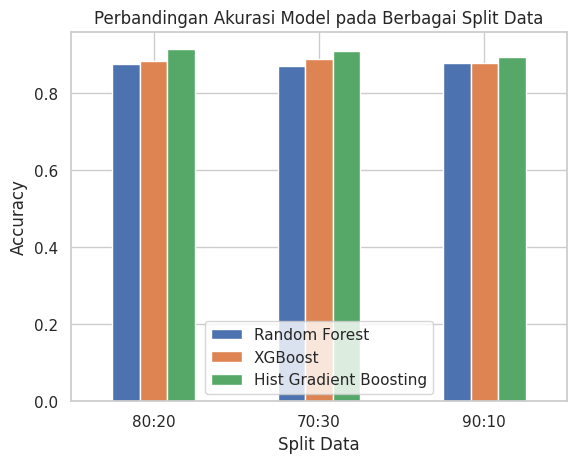

In [46]:
import matplotlib.pyplot as plt

comparison_df.set_index('Split Data').plot(kind='bar')
plt.title("Perbandingan Akurasi Model pada Berbagai Split Data")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

In [47]:
results = {
    "Random Forest": accuracy_score(y_test1, y_pred_rf),
    "XGBoost": accuracy_score(y_test1, y_pred_xgb),
    "Hist Gradient Boosting": accuracy_score(y_test1, y_pred_hgb)
}

best_model_name = max(results, key=results.get)
print("Model Terbaik:", best_model_name)

Model Terbaik: Hist Gradient Boosting


# **UJI COBA DATA BARU**


**1. LOAD MODEL**

In [ ]:
import joblib
import pandas as pd
import numpy as np

data = joblib.load('model_obesitas.pkl')

model = data['model']
scaler = data['scaler']
encoders = data['encoders']
le_target = data['label_encoder']
feature_names = data['feature_names']

**2. DATA BARU**

In [82]:
data_baru = pd.DataFrame([{
    'Age': 25,
        'Gender': 'Male',
        'Height': 1.70,
        'Weight': 75,
        'CALC': 'Sometimes',
        'FAVC': 'yes',
        'FCVC': 2,
        'NCP': 3,
        'SCC': 'no',
        'SMOKE': 'no',
        'CH2O': 2,
        'family_history_with_overweight': 'yes',
        'FAF': 1,
        'TUE': 3,
        'CAEC': 'Frequently',
        'MTRANS': 'Automobile'

}])

**3. BERSIHKAN STRING**

In [83]:
for col in data_baru.columns:
    if data_baru[col].dtype == 'object':
        data_baru[col] = data_baru[col].str.strip()

**4. ENCODING**

In [84]:
for col in data_baru.columns:
    if col in encoders:
        le = encoders[col]

        new_values = []
        for val in data_baru[col]:
            if val in le.classes_:
                new_values.append(le.transform([val])[0])
            else:
                print(f"⚠️ Value tidak dikenal di {col}: {val}")
                print("Isi kategori:", list(le.classes_))
                new_values.append(0)

        data_baru[col] = new_values

**5. UBAH JADI NUMERIK**

In [86]:
data_baru = data_baru.apply(pd.to_numeric, errors='coerce')
data_baru = data_baru.fillna(0)

In [87]:
print(data_baru)
print(data_baru.dtypes)

   Age  Gender  Height  Weight  CALC  FAVC  FCVC  NCP  SCC  SMOKE  CH2O  \
0   25     0.0     1.7      75   0.0   0.0     2    3  0.0    0.0     2   

   family_history_with_overweight  FAF  TUE  CAEC  MTRANS  
0                             0.0    1    3   0.0     0.0  
Age                                 int64
Gender                            float64
Height                            float64
Weight                              int64
CALC                              float64
FAVC                              float64
FCVC                                int64
NCP                                 int64
SCC                               float64
SMOKE                             float64
CH2O                                int64
family_history_with_overweight    float64
FAF                                 int64
TUE                                 int64
CAEC                              float64
MTRANS                            float64
dtype: object


**6. SAMAKAN URUTAN**

In [88]:
data_baru = data_baru[feature_names]

**7. SCALING**

In [89]:
data_scaled = scaler.transform(data_baru)


**PREDIKSI**

In [91]:
hasil = model.predict(data_scaled)
hasil_label = le_target.inverse_transform(hasil)

print("\n HASIL PREDIKSI:", hasil_label[0])


 HASIL PREDIKSI: Overweight_Level_I
